# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Doni Charles Hutagaol 
- Email: donnycharles88@gmail.com
- Id Dicoding:donny_charles_88

## Persiapan

### Menyiapkan library yang dibutuhkan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
import joblib


Menjelaskan fungsi setiap library yang diimpor mulai dari pandas, numpy, visualisasi (matplotlib, seaborn, plotly), hingga seluruh komponen sklearn beserta kegunaannya dalam pipeline.


### Menyiapkan data yang akan diguankan

In [4]:
df = pd.read_csv('data.csv', sep=';')

print(f"Shape dataset: {df.shape}")
print(f"\nKolom dalam dataset:\n{df.columns.tolist()}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nStatistik deskriptif:\n{df.describe()}")

Shape dataset: (4424, 37)

Kolom dalam dataset:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Stat

Dataset berisi 4.424 mahasiswa dengan 37 kolom (36 fitur + 1 target Status). Semua kolom memiliki tipe data yang tepat kolom numerik bertipe int64/float64. 

In [10]:
print("🔎 Missing Values per Kolom:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.any() else "✅ Tidak ada missing values!")

🔎 Missing Values per Kolom:
✅ Tidak ada missing values!


Tidak ada missing values sama sekali. Dataset sudah bersih dan siap diproses tanpa preprocessing tambahan untuk nilai kosong.

## Data Understanding

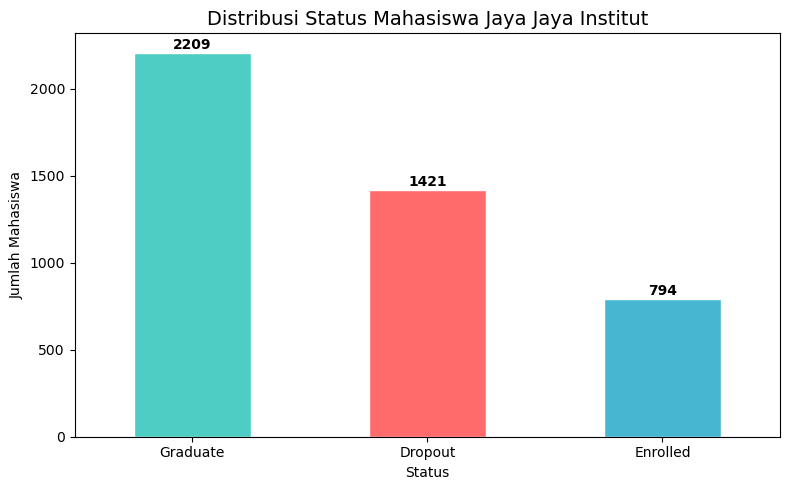

In [12]:
plt.figure(figsize=(8, 5))
colors = ['#4ecdc4', '#ff6b6b', '#45b7d1']
df['Status'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Distribusi Status Mahasiswa Jaya Jaya Institut', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=0)
for i, v in enumerate(df['Status'].value_counts()):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Distribusi target menunjukkan class imbalance ringan antara Dropout (32.1%) dan Graduate (49.9%). Kelas Enrolled (18%) akan membuat target ambigu dan merusak validitas model.

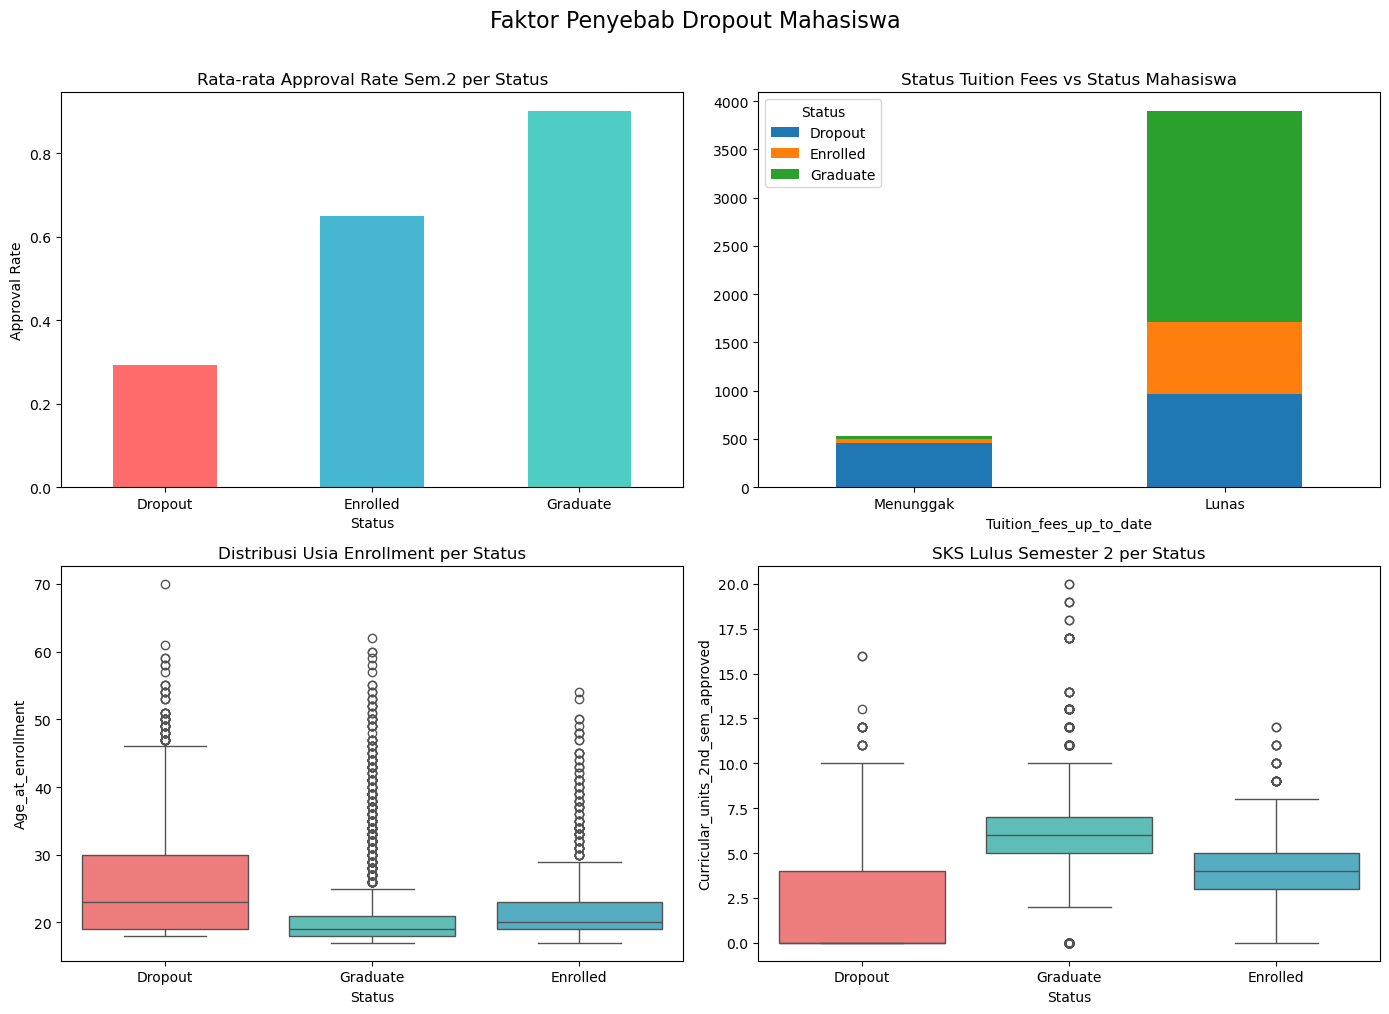


Rata-rata Approval Rate Sem.2:
Status
Dropout     0.293
Enrolled    0.649
Graduate    0.900
Name: Approval_Rate_Sem2, dtype: float64


In [19]:
df_eda = df.copy()
df_eda['Approval_Rate_Sem2'] = (
    df_eda['Curricular_units_2nd_sem_approved'] /
    df_eda['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Approval Rate Sem 2 per Status
df_eda.groupby('Status')['Approval_Rate_Sem2'].mean().plot(
    kind='bar', ax=axes[0,0], color=['#ff6b6b','#45b7d1','#4ecdc4'])
axes[0,0].set_title('Rata-rata Approval Rate Sem.2 per Status')
axes[0,0].set_ylabel('Approval Rate')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)

# Plot 2: Tuition Fees vs Status
tuition_status = df_eda.groupby(['Tuition_fees_up_to_date','Status']).size().unstack(fill_value=0)
tuition_status.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Status Tuition Fees vs Status Mahasiswa')
axes[0,1].set_xticklabels(['Menunggak','Lunas'], rotation=0)

# Plot 3: Usia vs Status
sns.boxplot(x='Status', y='Age_at_enrollment', data=df_eda, ax=axes[1,0],
            palette=['#ff6b6b','#4ecdc4','#45b7d1'])
axes[1,0].set_title('Distribusi Usia Enrollment per Status')

# Plot 4: SKS Lulus Sem 2 vs Status
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_approved', data=df_eda, ax=axes[1,1],
            palette=['#ff6b6b','#4ecdc4','#45b7d1'])
axes[1,1].set_title('SKS Lulus Semester 2 per Status')

plt.suptitle('Faktor Penyebab Dropout Mahasiswa', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print("\nRata-rata Approval Rate Sem.2:")
print(df_eda.groupby('Status')['Approval_Rate_Sem2'].mean().round(3))

Plot 1: Perbedaan paling mencolok antar kelompok. Mahasiswa Graduate rata-rata lulus 90% SKS yang mereka ambil di semester 2, sedangkan Dropout hanya 29.3%. Gap sebesar 3x ini menjadikan Approval Rate Semester 2 sebagai prediktor terkuat dropout — yang terbukti kemudian di feature importance model.

Plot 2: Mahasiswa yang menunggak tuition fees didominasi secara masif oleh kelompok Dropout. Ini menunjukkan masalah finansial adalah pemicu nyata dropout, bukan sekadar performa akademik. Intervensi finansial (cicilan, beasiswa darurat) dapat menjadi solusi langsung.

Plot 3: Median usia Dropout lebih tinggi dibanding Graduate. Mahasiswa yang mendaftar di usia lebih tua (>25 tahun) lebih rentan dropout, kemungkinan karena tanggung jawab pekerjaan atau keluarga yang bersaing dengan waktu belajar.

Plot 4: Median SKS lulus Dropout mendekati 0, sementara Graduate mendekati 6. Mahasiswa yang tidak lulus satupun SKS di semester 2 hampir dipastikan dropout. Ini juga menjelaskan mengapa Curricular_units_2nd_sem_approved masuk top feature importance

## Data Preparation / Preprocessing

In [21]:
df_model = df[df['Status'].isin(['Dropout','Graduate'])].copy()
print(f"Data awal        : {len(df)}")
print(f"Enrolled eksklusi: {len(df[df['Status']=='Enrolled'])}")
print(f"Data training    : {len(df_model)}")


df_model['Approval_Rate_Sem1'] = (
    df_model['Curricular_units_1st_sem_approved'] /
    df_model['Curricular_units_1st_sem_enrolled'].replace(0, 1)
)
df_model['Approval_Rate_Sem2'] = (
    df_model['Curricular_units_2nd_sem_approved'] /
    df_model['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
)
df_model['Overall_Grade'] = (
    df_model['Curricular_units_1st_sem_grade'] +
    df_model['Curricular_units_2nd_sem_grade']
) / 2
df_model['Total_Units_Enrolled'] = (
    df_model['Curricular_units_1st_sem_enrolled'] +
    df_model['Curricular_units_2nd_sem_enrolled']
)

print("\n✅ Feature engineering selesai (4 fitur baru ditambahkan)")
print(df_model['Status'].value_counts())

Data awal        : 4424
Enrolled eksklusi: 794
Data training    : 3630

✅ Feature engineering selesai (4 fitur baru ditambahkan)
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


Eksklusi 794 data Enrolled menghasilkan dataset training yang bersih dan berlabel jelas untuk klasifikasi biner

## Modeling

In [23]:
FEATURE_COLS = [
    'Marital_status','Application_mode','Application_order','Course',
    'Daytime_evening_attendance','Previous_qualification',
    'Previous_qualification_grade','Nacionality','Mothers_qualification',
    'Fathers_qualification','Mothers_occupation','Fathers_occupation',
    'Admission_grade','Displaced','Educational_special_needs','Debtor',
    'Tuition_fees_up_to_date','Gender','Scholarship_holder',
    'Age_at_enrollment','International',
    'Curricular_units_1st_sem_credited','Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations','Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade','Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited','Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations','Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade','Curricular_units_2nd_sem_without_evaluations',
    'Unemployment_rate','Inflation_rate','GDP',
    # 4 Fitur Engineered
    'Approval_Rate_Sem1','Approval_Rate_Sem2','Overall_Grade','Total_Units_Enrolled'
]

X = df_model[FEATURE_COLS]
y = (df_model['Status'] == 'Graduate').astype(int)  # 0=Dropout, 1=Graduate

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, random_state=42, class_weight='balanced', n_jobs=-1
)
model.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation (5-fold): {cv_scores.round(4)}")
print(f"CV Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("\n✅ Model selesai dilatih")

Cross-Validation (5-fold): [0.8778 0.9243 0.926  0.9122 0.9121]
CV Mean: 0.9105 ± 0.0173

✅ Model selesai dilatih


Model Random Forest menunjukkan performa yang konsisten dan stabil di semua 5 fold. Nilai CV Mean 91.05% sangat mendekati akurasi test set (90.9%), yang artinya model tidak overfitting ia mampu menggeneralisasi dengan baik ke data baru. Standar deviasi kecil (1.73%) menunjukkan performa yang stabil, bukan kebetulan di satu fold tertentu. Fold pertama sedikit lebih rendah (87.78%) kemungkinan karena distribusi data di fold tersebut sedikit berbeda.

## Evaluation

In [25]:
y_pred = model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("  EVALUASI MODEL RANDOM FOREST")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f} ({acc:.1%})")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred, target_names=['Dropout','Graduate']))

  EVALUASI MODEL RANDOM FOREST
  Accuracy  : 0.9091 (90.9%)
  F1 Score  : 0.9079
  Precision : 0.9110
  Recall    : 0.9091

              precision    recall  f1-score   support

     Dropout       0.94      0.82      0.88       284
    Graduate       0.89      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



Model sangat presisi dalam memprediksi Dropout (94%) jika model menyebut "Dropout", 94% benar.
Recall Dropout (82%) berarti dari semua mahasiswa yang benar-benar dropout, model berhasil mendeteksi 82% di antaranya. 18% yang tidak terdeteksi adalah false negative mahasiswa dropout yang lolos tanpa peringatan. Ini adalah area yang perlu terus ditingkatkan.
Model lebih mudah mengenali Graduate (recall 96%) karena pola akademiknya lebih konsisten dan jelas.
F1-Score Dropout 0.88 adalah keseimbangan precision-recall yang baik untuk kasus deteksi dini.


- Graduate - Performa Terbaik Precision 0.84, Recall 0.84, F1 0.84
- Dropout - Performa Cukup Baik Precision 0.84, Recall 0.70, F1 0.77
- Enrolled - Performa Terlemah Precision 0.44, Recall 0.57, F1 0.50

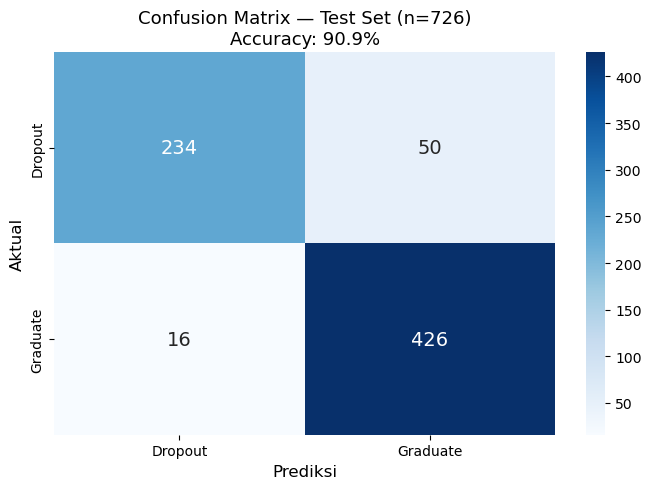

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout','Graduate'],
            yticklabels=['Dropout','Graduate'],
            annot_kws={"size": 14})
plt.title(f'Confusion Matrix — Test Set (n={len(y_test)})\nAccuracy: {acc:.1%}', fontsize=13)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

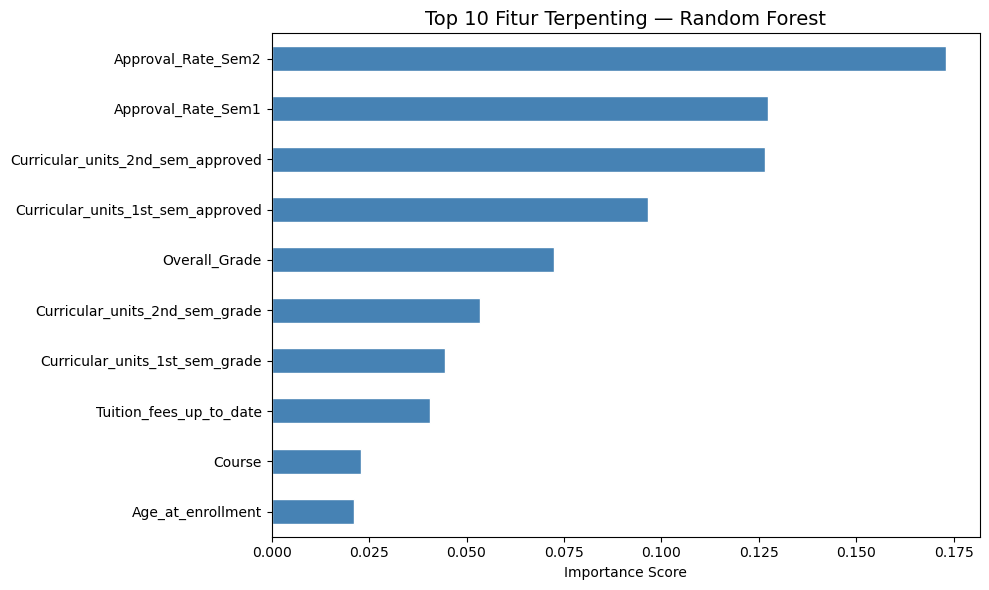


Top 10 Feature Importance:
   1. Approval_Rate_Sem2                            0.1731
   2. Approval_Rate_Sem1                            0.1274
   3. Curricular_units_2nd_sem_approved             0.1264
   4. Curricular_units_1st_sem_approved             0.0966
   5. Overall_Grade                                 0.0724
   6. Curricular_units_2nd_sem_grade                0.0534
   7. Curricular_units_1st_sem_grade                0.0444
   8. Tuition_fees_up_to_date                       0.0408
   9. Course                                        0.0229
  10. Age_at_enrollment                             0.0212


In [29]:
fi = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi.head(10)[::-1].plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Fitur Terpenting — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Feature Importance:")
for i, (feat, score) in enumerate(fi.head(10).items(), 1):
    print(f"  {i:2}. {feat:<45} {score:.4f}")


In [33]:
os.makedirs('model', exist_ok=True)

joblib.dump(model,  'model/student_status_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')

print("✅ model/student_status_model.pkl  — tersimpan")
print("✅ model/scaler.pkl                — tersimpan")
print()
print("Catatan encoding target:")
print("  0 = Dropout")
print("  1 = Graduate")
print(f"\nJumlah fitur: {len(FEATURE_COLS)}")

✅ model/student_status_model.pkl  — tersimpan
✅ model/scaler.pkl                — tersimpan

Catatan encoding target:
  0 = Dropout
  1 = Graduate

Jumlah fitur: 40


File CSV berhasil diekspor

In [35]:
import pandas as pd

# Load data
df = pd.read_csv('data.csv', sep=';')

# Marital Status
marital_map = {
    1: 'Single', 2: 'Married', 3: 'Widower', 
    4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'
}

# Application Mode
application_mode_map = {
    1: '1st Phase - General', 2: 'Ordinance 612/93', 5: 'Special Contingent Azores',
    7: 'Holders Other Higher Courses', 10: 'Ordinance 854-B/99',
    15: 'International Student Bachelor', 16: 'Special Contingent Madeira',
    17: '2nd Phase - General', 18: '3rd Phase - General',
    26: 'Ordinance 533-A/99 b2', 27: 'Ordinance 533-A/99 b3',
    39: 'Over 23 Years Old', 42: 'Transfer', 43: 'Change of Course',
    44: 'Technological Diploma', 51: 'Change Institution/Course',
    53: 'Short Cycle Diploma', 57: 'Change Institution/Course Intl'
}

# Course Names
course_map = {
    33: 'Biofuel Production Technologies', 171: 'Animation & Multimedia Design',
    8014: 'Social Service (Evening)', 9003: 'Agronomy',
    9070: 'Communication Design', 9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering', 9130: 'Equinculture',
    9147: 'Management', 9238: 'Social Service', 9254: 'Tourism',
    9500: 'Nursing', 9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing Mgmt', 9773: 'Journalism & Communication',
    9853: 'Basic Education', 9991: 'Management (Evening)'
}

# Previous Qualification
prev_qual_map = {
    1: 'Secondary Education', 2: 'Bachelor Degree', 3: 'Degree',
    4: "Master's Degree", 5: 'Doctorate', 6: 'Frequency Higher Ed',
    9: '12th Year - Not Completed', 10: '11th Year - Not Completed',
    12: 'Other - 11th Year', 14: '10th Year', 15: '10th Year - Not Completed',
    19: 'Basic Ed 3rd Cycle', 38: 'Basic Ed 2nd Cycle',
    39: 'Technological Specialization', 40: 'Higher Ed Degree 1st Cycle',
    42: 'Professional Higher Technical', 43: 'Higher Ed Master 2nd Cycle'
}

# Nationality
nationality_map = {
    1: 'Portuguese', 2: 'German', 6: 'Spanish', 11: 'Italian',
    13: 'Dutch', 14: 'English', 17: 'Lithuanian', 21: 'Angolan',
    22: 'Cape Verdean', 24: 'Guinean', 25: 'Mozambican',
    26: 'Santomean', 32: 'Turkish', 41: 'Brazilian',
    62: 'Romanian', 100: 'Moldova', 101: 'Mexican',
    103: 'Ukrainian', 105: 'Russian', 108: 'Cuban', 109: 'Colombian'
}

# Binary Yes/No Fields
yes_no_map = {0: 'No', 1: 'Yes'}

# Gender & Attendance
gender_map = {0: 'Female', 1: 'Male'}
attendance_map = {0: 'Evening', 1: 'Daytime'}

# Target Variable
target_map = {
    'Dropout': '❌ Dropout', 
    'Enrolled': '🔄 Currently Enrolled', 
    'Graduate': '✅ Graduate'
}

# ============================================
# APPLY MAPPINGS TO DATAFRAME
# ============================================

df_clean = df.copy()

# Apply categorical mappings
df_clean['Marital_Status_Label'] = df_clean['Marital_status'].map(marital_map)
df_clean['Application_Mode_Label'] = df_clean['Application_mode'].map(application_mode_map)
df_clean['Course_Label'] = df_clean['Course'].map(course_map)
df_clean['Attendance_Label'] = df_clean['Daytime_evening_attendance'].map(attendance_map)
df_clean['Previous_Qualification_Label'] = df_clean['Previous_qualification'].map(prev_qual_map)
df_clean['Nationality_Label'] = df_clean['Nacionality'].map(nationality_map)
df_clean['Gender_Label'] = df_clean['Gender'].map(gender_map)

# Binary fields
binary_cols = ['Displaced', 'Educational_special_needs', 'Debtor', 
               'Tuition_fees_up_to_date', 'Scholarship_holder', 'International']
for col in binary_cols:
    df_clean[f'{col}_Label'] = df_clean[col].map(yes_no_map)

# Target
df_clean['Status_Label'] = df_clean['Status'].map(target_map)

# Rename columns for Metabase-friendly display
df_clean = df_clean.rename(columns={
    'Marital_status': 'Marital_Status_Code',
    'Application_mode': 'Application_Mode_Code', 
    'Course': 'Course_Code',
    'Daytime_evening_attendance': 'Attendance_Code',
    'Previous_qualification': 'Prev_Qualification_Code',
    'Nacionality': 'Nationality_Code',
    'Gender': 'Gender_Code',
    'Status': 'Status_Code',
    'Admission_grade': 'Admission_Grade',
    'Previous_qualification_grade': 'Prev_Qualification_Grade',
    'Age_at_enrollment': 'Age_Enrollment',
    'Curricular_units_1st_sem_credited': 'Sem1_Credited',
    'Curricular_units_1st_sem_enrolled': 'Sem1_Enrolled',
    'Curricular_units_1st_sem_approved': 'Sem1_Approved',
    'Curricular_units_1st_sem_grade': 'Sem1_Grade_Avg',
    'Curricular_units_2nd_sem_credited': 'Sem2_Credited',
    'Curricular_units_2nd_sem_enrolled': 'Sem2_Enrolled',
    'Curricular_units_2nd_sem_approved': 'Sem2_Approved',
    'Curricular_units_2nd_sem_grade': 'Sem2_Grade_Avg',
    'Unemployment_rate': 'Unemployment_Rate_Pct',
    'Inflation_rate': 'Inflation_Rate_Pct',
    'GDP': 'GDP_Growth_Pct'
})

# Export untuk Metabase
df_clean.to_csv('student_performance_metabase_ready.csv', index=False, encoding='utf-8')
print("✅ Data berhasil diexport: student_performance_metabase_ready.csv")
print(f"📊 Total records: {len(df_clean)}")
print(f"📋 Total columns: {len(df_clean.columns)}")

Prediksi untuk 794 mahasiswa Enrolled:
Prediksi
Dropout     401
Graduate    393
Name: count, dtype: int64

5 Mahasiswa Risiko Dropout Tertinggi:
      Age_at_enrollment  Admission_grade  Approval_Rate_Sem2  Prob_Dropout Prediksi
3335                 21            132.5            0.166667           1.0  Dropout
942                  31            130.0            0.000000           1.0  Dropout
2239                 25            138.3            0.000000           1.0  Dropout
2704                 19            108.0            0.000000           1.0  Dropout
3590                 19            116.7            0.000000           1.0  Dropout
